# DES432 Statistics and Data Modeling  
## Project 2: Statistical Modeling & Interpretation  

---

### Objective

The objective of this project is to apply statistical modeling techniques to analyze real-world data.  
We aim to understand the relationship between weather conditions and bike rental demand using regression analysis.

---

## Bike Sharing Demand Analysis

This notebook analyzes the **Bike Sharing dataset** using `day.csv`.

The main goal is to understand how weather variables affect daily bike rental demand.

### Variables

**Response variable (Y):**  
- `cnt` = total number of bike rentals per day  

**Predictor variables (X):**  
- `temp` = normalized temperature  
- `hum` = normalized humidity  
- `windspeed` = normalized wind speed  

---

### Research Question

How do temperature, humidity, and windspeed affect daily bike rentals?

**Main structure:**
1. Data acquisition and understanding  
2. Variable selection and data cleaning  
3. Exploratory data analysis  
4. Modeling  
5. Hypothesis testing  
6. Model evaluation  
7. Residual analysis and error discussion  
8. Final summary, insights, and limitations

## 1. Data Acquisition

In this step, we download the dataset from Google Drive and load `day.csv` into Python.

In [1]:
# ============================================================
# 1. DATA ACQUISITION
# ============================================================

!pip install -q gdown

import os
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Create data folder
os.makedirs("data", exist_ok=True)

# Google Drive folder link
folder_url = "https://drive.google.com/drive/folders/12Y7SAX-TBmPsINR0CO-kjL8RTSHtDivE?usp=sharing"

# Download folder from Google Drive
gdown.download_folder(
    url=folder_url,
    output="data",
    quiet=False,
    use_cookies=False
)

# Check files
print("Files in data folder:")
print(os.listdir("data"))

# Load day.csv
file_path = "data/day.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
display(df.head())

Retrieving folder contents


Processing file 1m2wybtzLz7PHTxBF3Vk8psvheBVXwRIB day.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1m2wybtzLz7PHTxBF3Vk8psvheBVXwRIB
To: /content/data/day.csv
100%|██████████| 57.6k/57.6k [00:00<00:00, 13.4MB/s]

Files in data folder:
['day.csv']
Dataset loaded successfully!



Download completed


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## 2. Data Understanding

This section checks the structure of the dataset before analysis, including the dataset shape, columns, data types, missing values, duplicate rows, and preview of the data.

In [2]:
# ============================================================
# 2. DATA UNDERSTANDING
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic information:")
df.info()

Dataset shape:
(731, 16)

Column names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Data types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicate rows:
0

Basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 

## 3. Define Variables

For this project, we focus only on the variables needed for the regression analysis.

**Response variable (Y):** `cnt`  
**Predictor variables (X):** `temp`, `hum`, `windspeed`

The variables `casual` and `registered` are not used because they are components of `cnt`, which would cause data leakage.

In [3]:
# ============================================================
# 3. DEFINE VARIABLES
# ============================================================

# Response variable (Y)
Y_variable = "cnt"

# Predictor variables (X)
X_variables = ["temp", "hum", "windspeed"]

# Create selected dataset
data = df[[Y_variable] + X_variables].copy()

print("Selected variables:")
display(data.head())

print("\nSelected data shape:")
print(data.shape)

Selected variables:


,cnt,temp,hum,windspeed
0,985,0.344167,0.805833,0.160446
1,801,0.363478,0.696087,0.248539
2,1349,0.196364,0.437273,0.248309
3,1562,0.200000,0.590435,0.160296
4,1600,0.226957,0.436957,0.186900



Selected data shape:
(731, 4)


## 4. Check Excluded Variable: `temp` vs `atemp`

Before finalizing the predictors, we check the relationship between `temp` and `atemp`.

`atemp` means feeling temperature. Since it is very similar to `temp`, using both variables in the same regression model may create redundancy or multicollinearity.

In [4]:
# ============================================================
# 7. CHECK MULTICOLLINEARITY ISSUE: temp vs atemp
# ============================================================

temp_atemp_corr = df[["temp", "atemp"]].corr()

print("Correlation between temp and atemp:")
display(temp_atemp_corr)


Correlation between temp and atemp:


,temp,atemp
temp,1.000000,0.991702
atemp,0.991702,1.000000


### Interpretation

The correlation between `temp` and `atemp` is very high, meaning both variables explain almost the same temperature information.

Therefore, only `temp` is used in the final models. This makes the regression model easier to interpret and avoids using two highly similar predictors.

## 5. Data Cleaning

This step prepares the selected data for analysis.

The cleaning process includes:
- removing duplicate rows
- converting selected variables to numeric format
- removing missing values
- checking the range of selected variables

In [5]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

# Remove duplicate rows
data = data.drop_duplicates()

# Convert variables to numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Remove missing values
data = data.dropna()

# Check valid values
print("After cleaning:")
print(data.shape)

print("\nMissing values after cleaning:")
print(data.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(data.duplicated().sum())

print("\nSummary after cleaning:")
display(data.describe())

# Check valid ranges
print("\nMinimum values:")
print(data.min())

print("\nMaximum values:")
print(data.max())

After cleaning:
(731, 4)

Missing values after cleaning:
cnt          0
temp         0
hum          0
windspeed    0
dtype: int64

Duplicate rows after cleaning:
0

Summary after cleaning:


,cnt,temp,hum,windspeed
count,731.000000,731.000000,731.000000,731.000000
mean,4504.348837,0.495385,0.627894,0.190486
std,1937.211452,0.183051,0.142429,0.077498
min,22.000000,0.059130,0.000000,0.022392
25%,3152.000000,0.337083,0.520000,0.134950
50%,4548.000000,0.498333,0.626667,0.180975
75%,5956.000000,0.655417,0.730209,0.233214
max,8714.000000,0.861667,0.972500,0.507463



Minimum values:
cnt          22.000000
temp          0.059130
hum           0.000000
windspeed     0.022392
dtype: float64

Maximum values:
cnt          8714.000000
temp            0.861667
hum             0.972500
windspeed       0.507463
dtype: float64


## 6. Exploratory Data Analysis: Summary Statistics

This section gives a numerical overview of the selected variables.

We calculate:
- mean
- standard deviation
- minimum and maximum values
- quartiles
- correlation between variables

In [6]:
# ============================================================
# 5. EDA: SUMMARY STATISTICS
# ============================================================

print("Summary statistics for selected variables:")
display(data.describe())

print("\nCorrelation matrix:")
corr_matrix = data.corr()
display(corr_matrix)

Summary statistics for selected variables:


,cnt,temp,hum,windspeed
count,731.000000,731.000000,731.000000,731.000000
mean,4504.348837,0.495385,0.627894,0.190486
std,1937.211452,0.183051,0.142429,0.077498
min,22.000000,0.059130,0.000000,0.022392
25%,3152.000000,0.337083,0.520000,0.134950
50%,4548.000000,0.498333,0.626667,0.180975
75%,5956.000000,0.655417,0.730209,0.233214
max,8714.000000,0.861667,0.972500,0.507463



Correlation matrix:


,cnt,temp,hum,windspeed
cnt,1.000000,0.627494,-0.100659,-0.234545
temp,0.627494,1.000000,0.126963,-0.157944
hum,-0.100659,0.126963,1.000000,-0.248489
windspeed,-0.234545,-0.157944,-0.248489,1.000000


## 7. Exploratory Data Analysis: Visualizations

This section uses graphs to understand the distribution and relationships in the data.

The visualizations include:
- histogram of daily bike rentals
- scatterplot of temperature vs bike rentals
- scatterplot of humidity vs bike rentals
- scatterplot of windspeed vs bike rentals
- correlation heatmap

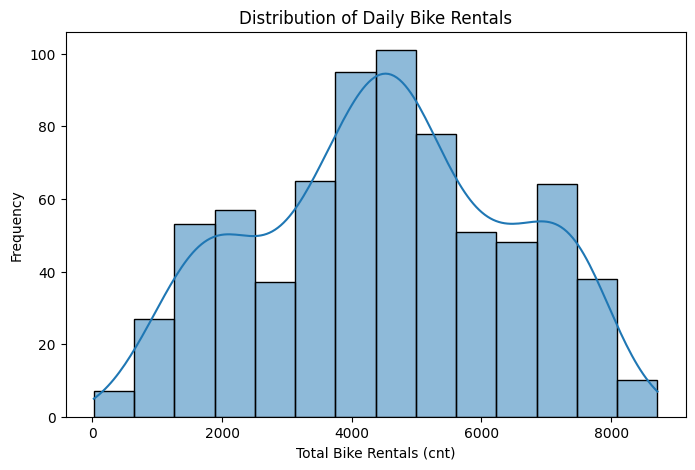

In [7]:
# ============================================================
# 6. EDA: VISUALIZATION
# ============================================================

# Histogram of bike rentals
plt.figure(figsize=(8,5))
sns.histplot(data["cnt"], kde=True)
plt.title("Distribution of Daily Bike Rentals")
plt.xlabel("Total Bike Rentals (cnt)")
plt.ylabel("Frequency")
plt.show()

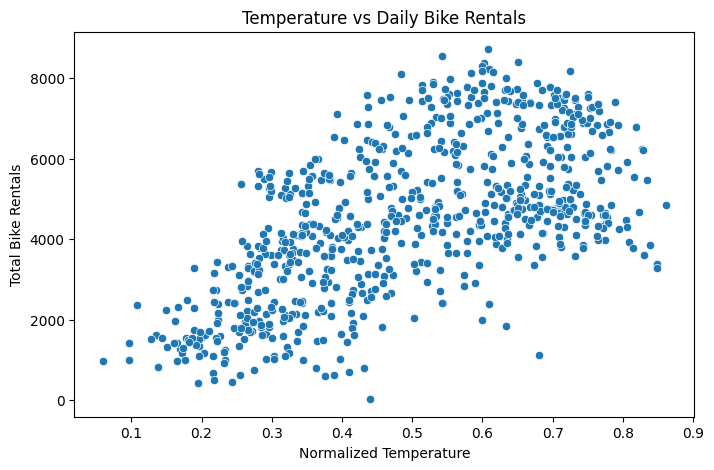

In [8]:
# Scatterplot: temp vs cnt
plt.figure(figsize=(8,5))
sns.scatterplot(x="temp", y="cnt", data=data)
plt.title("Temperature vs Daily Bike Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Bike Rentals")
plt.show()

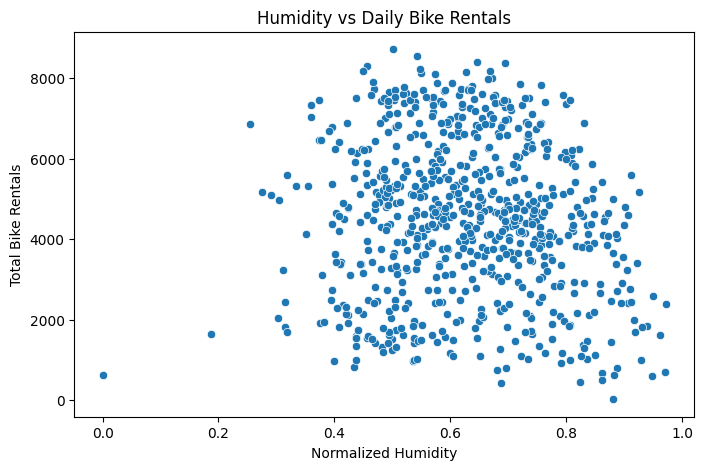

In [9]:
# Scatterplot: hum vs cnt
plt.figure(figsize=(8,5))
sns.scatterplot(x="hum", y="cnt", data=data)
plt.title("Humidity vs Daily Bike Rentals")
plt.xlabel("Normalized Humidity")
plt.ylabel("Total Bike Rentals")
plt.show()

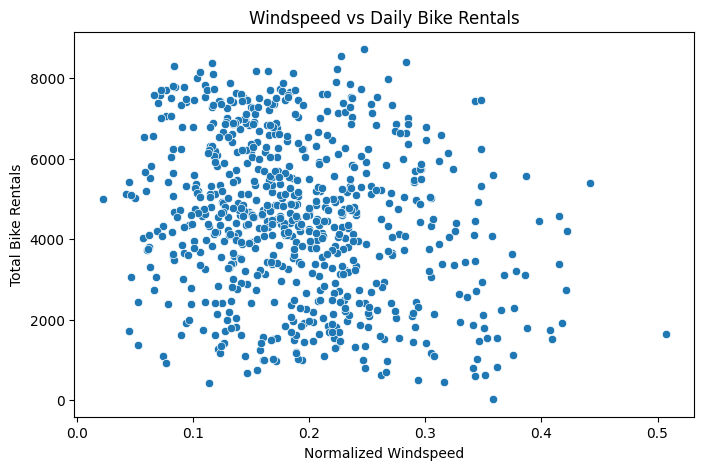

In [10]:
# Scatterplot: windspeed vs cnt
plt.figure(figsize=(8,5))
sns.scatterplot(x="windspeed", y="cnt", data=data)
plt.title("Windspeed vs Daily Bike Rentals")
plt.xlabel("Normalized Windspeed")
plt.ylabel("Total Bike Rentals")
plt.show()

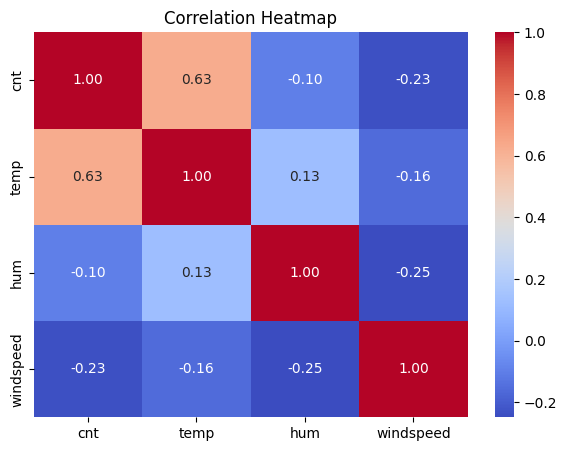

In [11]:
# Correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 8. Model 1: Simple Linear Regression

Model 1 examines the relationship between temperature and daily bike rentals.

**Model form:**

`cnt = β₀ + β₁(temp)`

This model is useful for checking whether temperature alone explains part of the variation in bike rental demand.

In [12]:
# ============================================================
# Model 1: Simple Linear Regression (cnt ~ temp)
# ============================================================

import pandas as pd

X1 = data[["temp"]]
Y = data["cnt"]

# Add intercept
X1_const = sm.add_constant(X1)

# Fit model
model1 = sm.OLS(Y, X1_const).fit()

# Extract important results
results_model1 = pd.DataFrame({
    "Metric": ["Intercept (β0)", "Temp Coefficient (β1)", "R-squared", "P-value (temp)"],
    "Value": [
        model1.params["const"],
        model1.params["temp"],
        model1.rsquared,
        model1.pvalues["temp"]
    ]
})

results_model1

,Metric,Value
0,Intercept (β0),1.214642e+03
1,Temp Coefficient (β1),6.640710e+03
2,R-squared,3.937487e-01
3,P-value (temp),2.810622e-81


## 9. Model 1: Prediction and Evaluation

After building Model 1, we calculate prediction and error metrics.

The metrics include:
- R-squared
- Adjusted R-squared
- MSE
- RMSE
- MAE

In [13]:
# ============================================================
# 9. MODEL 1: PREDICTION AND EVALUATION
# ============================================================

data["pred_model1"] = model1.predict(X1_const)
data["resid_model1"] = data["cnt"] - data["pred_model1"]

mse_model1 = mean_squared_error(data["cnt"], data["pred_model1"])
rmse_model1 = np.sqrt(mse_model1)
mae_model1 = mean_absolute_error(data["cnt"], data["pred_model1"])

print("Model 1 Evaluation:")
print("R-squared:", model1.rsquared)
print("Adjusted R-squared:", model1.rsquared_adj)
print("MSE:", mse_model1)
print("RMSE:", rmse_model1)
print("MAE:", mae_model1)

Model 1 Evaluation:
R-squared: 0.3937487313729242
Adjusted R-squared: 0.3929171109770023
MSE: 2272020.2556456514
RMSE: 1507.3222136111613
MAE: 1246.3583947400484


## 10. Model 1: Regression Line Visualization

This graph shows the simple linear relationship between temperature and daily bike rentals.

This visualization is useful for EDA and explanation, but the final model selection should be based on the model evaluation results.

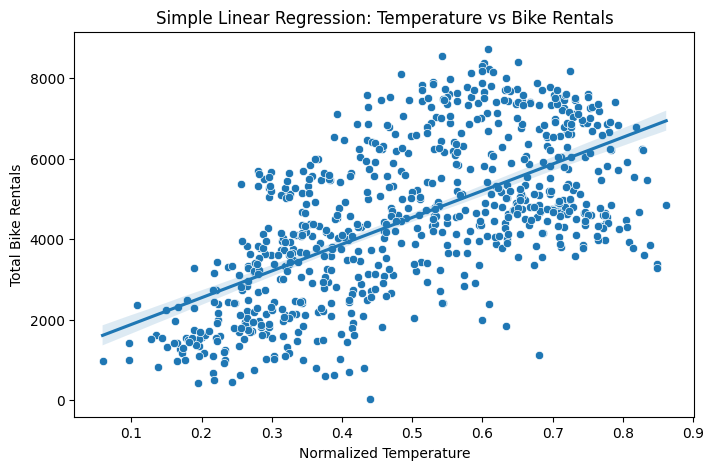

In [14]:
# ============================================================
# 10. MODEL 1: REGRESSION LINE VISUALIZATION
# ============================================================

plt.figure(figsize=(8,5))
sns.scatterplot(x="temp", y="cnt", data=data)
sns.regplot(x="temp", y="cnt", data=data, scatter=False)
plt.title("Simple Linear Regression: Temperature vs Bike Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Bike Rentals")
plt.show()

## 11. Model 2: Multiple Linear Regression

Model 2 includes three weather-related predictors: temperature, humidity, and windspeed.

**Model form:**

`cnt = β₀ + β₁(temp) + β₂(hum) + β₃(windspeed)`

This model is more complete than Model 1 because it considers more than one weather condition at the same time.

In [15]:
# ============================================================
# 11. MODEL 2: MULTIPLE LINEAR REGRESSION
# Model 2: cnt ~ temp + hum + windspeed
# ============================================================

import pandas as pd

# Select predictors and response variable
X2 = data[["temp", "hum", "windspeed"]]
Y = data["cnt"]

# Add intercept
X2_const = sm.add_constant(X2)

# Fit multiple linear regression model
model2 = sm.OLS(Y, X2_const).fit()

# Create clean summary table
results_model2 = pd.DataFrame({
    "Metric": [
        "Intercept (β0)",
        "Temp Coefficient (β1)",
        "Humidity Coefficient (β2)",
        "Windspeed Coefficient (β3)",
        "R-squared",
        "Adjusted R-squared",
        "P-value (temp)",
        "P-value (hum)",
        "P-value (windspeed)"
    ],
    "Value": [
        f"{model2.params['const']:.4f}",
        f"{model2.params['temp']:.4f}",
        f"{model2.params['hum']:.4f}",
        f"{model2.params['windspeed']:.4f}",
        f"{model2.rsquared:.4f}",
        f"{model2.rsquared_adj:.4f}",
        f"{model2.pvalues['temp']:.4e}",
        f"{model2.pvalues['hum']:.4e}",
        f"{model2.pvalues['windspeed']:.4e}"
    ]
})

display(results_model2)

,Metric,Value
0,Intercept (β0),4084.3634
1,Temp Coefficient (β1),6625.5327
2,Humidity Coefficient (β2),-3100.1231
3,Windspeed Coefficient (β3),-4806.9293
4,R-squared,0.4609
5,Adjusted R-squared,0.4587
6,P-value (temp),4.1807e-86
7,P-value (hum),2.8330e-15
8,P-value (windspeed),2.4754e-11


## 12. Interpretation of Coefficients from Model 2

Each coefficient in the multiple regression model is interpreted while holding the other predictors constant.

This section helps explain the direction and meaning of each predictor before moving to hypothesis testing and model evaluation.

In [16]:
# ============================================================
# 16. INTERPRET COEFFICIENTS FROM MULTIPLE REGRESSION
# ============================================================

import pandas as pd

# Create clean coefficient table
coef_table = pd.DataFrame({
    "Variable": model2.params.index,
    "Coefficient": model2.params.values,
    "P-value": model2.pvalues.values
})

# Round values for readability
coef_table["Coefficient"] = coef_table["Coefficient"].round(4)
coef_table["P-value"] = coef_table["P-value"]

display(coef_table)

# Create readable regression equation
equation = (
    f"cnt = {model2.params['const']:.2f} "
    f"+ ({model2.params['temp']:.2f}) × temp "
    f"+ ({model2.params['hum']:.2f}) × hum "
    f"+ ({model2.params['windspeed']:.2f}) × windspeed"
)

print("Regression Equation:")
print(equation)


,Variable,Coefficient,P-value
0,const,4084.3634,8.709754e-31
1,temp,6625.5327,4.180718e-86
2,hum,-3100.1231,2.833008e-15
3,windspeed,-4806.9293,2.475445e-11


Regression Equation:
cnt = 4084.36 + (6625.53) × temp + (-3100.12) × hum + (-4806.93) × windspeed


### Interpretation

**Temperature:** Holding humidity and windspeed constant, a 1-unit increase in normalized temperature is associated with an increase in daily bike rentals.

**Humidity:** Holding temperature and windspeed constant, a 1-unit increase in normalized humidity is associated with a decrease in daily bike rentals.

**Windspeed:** Holding temperature and humidity constant, a 1-unit increase in normalized windspeed is associated with a decrease in daily bike rentals.

Because the predictors are normalized, these coefficients should be interpreted as changes along the normalized scale, not original physical units.

## 13. Inference: Hypothesis Testing

This section tests whether each predictor is statistically associated with daily bike rental demand.

The significance level is:

`α = 0.05`

The hypothesis tests are placed after the regression models because the t-statistics and p-values come from `model1` and `model2`.

### 13.1 Hypothesis Testing for Model 1: Temperature

For the simple linear regression model:

**H₀:** β₁ = 0  
Temperature is not significantly associated with bike rentals.

**H₁:** β₁ ≠ 0  
Temperature is significantly associated with bike rentals.

In [17]:
# ============================================================
# HYPOTHESIS TESTING FOR MODEL 1
# Simple Linear Regression: cnt ~ temp
# ============================================================

alpha = 0.05

temp_coef_model1 = model1.params["temp"]
temp_tvalue_model1 = model1.tvalues["temp"]
temp_pvalue_model1 = model1.pvalues["temp"]

model1_hypothesis = pd.DataFrame({
    "Model": ["Model 1: cnt ~ temp"],
    "Variable": ["temp"],
    "Hypothesis": ["H0: β1 = 0, H1: β1 ≠ 0"],
    "Coefficient": [round(temp_coef_model1, 4)],
    "t-statistic": [round(temp_tvalue_model1, 4)],
    "p-value": [f"{temp_pvalue_model1:.4e}"],
    "Significance level (α)": [alpha],
    "Decision": [
        "Reject H0" if temp_pvalue_model1 < alpha else "Fail to reject H0"
    ]
})

display(model1_hypothesis)

,Model,Variable,Hypothesis,Coefficient,t-statistic,p-value,Significance level (α),Decision
0,Model 1: cnt ~ temp,temp,"H0: β1 = 0, H1: β1 ≠ 0",6640.71,21.7594,2.8106e-81,0.05,Reject H0


### Interpretation

Since the p-value is less than 0.05, we reject H₀.

This means there is sufficient statistical evidence to conclude that temperature is significantly associated with daily bike rental demand in the simple linear regression model.

### 13.2 Hypothesis Testing for Model 2: Temperature, Humidity, and Windspeed

For the multiple linear regression model, each predictor is tested while holding the other predictors constant.

The tests are:

- Temperature: H₀: β₁ = 0, H₁: β₁ ≠ 0
- Humidity: H₀: β₂ = 0, H₁: β₂ ≠ 0
- Windspeed: H₀: β₃ = 0, H₁: β₃ ≠ 0

In [18]:
# ============================================================
# 12. HYPOTHESIS TESTING FOR MULTIPLE LINEAR REGRESSION
# ============================================================

import pandas as pd

alpha = 0.05

variables = ["temp", "hum", "windspeed"]

hypothesis_results = pd.DataFrame({
    "Variable": variables,
    "Hypothesis": [
        "H0: β1 = 0, H1: β1 ≠ 0",
        "H0: β2 = 0, H1: β2 ≠ 0",
        "H0: β3 = 0, H1: β3 ≠ 0"
    ],
    "Coefficient": [model2.params[var] for var in variables],
    "Standard Error": [model2.bse[var] for var in variables],
    "t-statistic": [model2.tvalues[var] for var in variables],
    "p-value": [model2.pvalues[var] for var in variables],
    "Significance level (α)": [alpha] * len(variables),
    "Decision": [
        "Reject H0" if model2.pvalues[var] < alpha else "Fail to reject H0"
        for var in variables
    ]
})

# Round normal columns only
hypothesis_results["Coefficient"] = hypothesis_results["Coefficient"].round(4)
hypothesis_results["Standard Error"] = hypothesis_results["Standard Error"].round(4)
hypothesis_results["t-statistic"] = hypothesis_results["t-statistic"].round(4)

# Format p-value in scientific notation
hypothesis_results["p-value"] = hypothesis_results["p-value"].apply(lambda x: f"{x:.4e}")

display(hypothesis_results)

,Variable,Hypothesis,Coefficient,Standard Error,t-statistic,p-value,Significance level (α),Decision
0,temp,"H0: β1 = 0, H1: β1 ≠ 0",6625.5327,293.0854,22.6062,4.1807e-86,0.05,Reject H0
1,hum,"H0: β2 = 0, H1: β2 ≠ 0",-3100.1231,383.9916,-8.0734,2.8330e-15,0.05,Reject H0
2,windspeed,"H0: β3 = 0, H1: β3 ≠ 0",-4806.9293,708.9042,-6.7808,2.4754e-11,0.05,Reject H0


### Interpretation

If the p-value for a predictor is less than 0.05, we reject H₀ for that predictor.

In this model, temperature, humidity, and windspeed are statistically significant predictors of daily bike rental demand while holding the other variables constant.

## 14. Model 2: Prediction and Evaluation

This section evaluates the multiple regression model using the same performance measures as Model 1.

This allows Model 1 and Model 2 to be compared fairly.

In [19]:
# ============================================================
# 13. MODEL 2: PREDICTION AND EVALUATION
# ============================================================

data["pred_model2"] = model2.predict(X2_const)
data["resid_model2"] = data["cnt"] - data["pred_model2"]

mse_model2 = mean_squared_error(data["cnt"], data["pred_model2"])
rmse_model2 = np.sqrt(mse_model2)
mae_model2 = mean_absolute_error(data["cnt"], data["pred_model2"])

print("Model 2 Evaluation:")
print("R-squared:", model2.rsquared)
print("Adjusted R-squared:", model2.rsquared_adj)
print("MSE:", mse_model2)
print("RMSE:", rmse_model2)
print("MAE:", mae_model2)

Model 2 Evaluation:
R-squared: 0.4608950096446517
Adjusted R-squared: 0.4586703673185636
MSE: 2020379.2080812177
RMSE: 1421.400439032301
MAE: 1164.1469477315181


## 15. Model Comparison

This section compares Model 1 and Model 2 using:

- R-squared
- Adjusted R-squared
- MSE
- RMSE
- MAE

Model 2 should be selected if it has higher explanatory power and lower prediction error.

In [20]:
# ============================================================
# 15. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Model 1: cnt ~ temp",
        "Model 2: cnt ~ temp + hum + windspeed"
    ],
    "R-squared": [
        model1.rsquared,
        model2.rsquared
    ],
    "Adjusted R-squared": [
        model1.rsquared_adj,
        model2.rsquared_adj
    ],
    "MSE": [
        mse_model1,
        mse_model2
    ],
    "RMSE": [
        rmse_model1,
        rmse_model2
    ],
    "MAE": [
        mae_model1,
        mae_model2
    ]
})

# Round values for readability
comparison[["R-squared", "Adjusted R-squared", "MSE", "RMSE", "MAE"]] = comparison[
    ["R-squared", "Adjusted R-squared", "MSE", "RMSE", "MAE"]
].round(4)

# Display clean comparison table
display(comparison)

,Model,R-squared,Adjusted R-squared,MSE,RMSE,MAE
0,Model 1: cnt ~ temp,0.3937,0.3929,2.272020e+06,1507.3222,1246.3584
1,Model 2: cnt ~ temp + hum + windspeed,0.4609,0.4587,2.020379e+06,1421.4004,1164.1469


### Interpretation

Model 2 has higher R-squared and Adjusted R-squared than Model 1, meaning it explains more variation in daily bike rentals.

Model 2 also has lower RMSE and MAE, meaning its prediction errors are smaller.

Therefore, Model 2 is selected as the final model. However, the improvement is moderate, so the model is useful for general interpretation but not perfect for exact daily prediction.

## 16. Residual Analysis for Model 2

Since Model 2 is selected as the final model, residual analysis is performed for Model 2.

This section checks:
- whether residuals are mostly scattered around zero
- whether the residual distribution is roughly centered around zero
- whether there are signs of imperfect fit or remaining prediction error

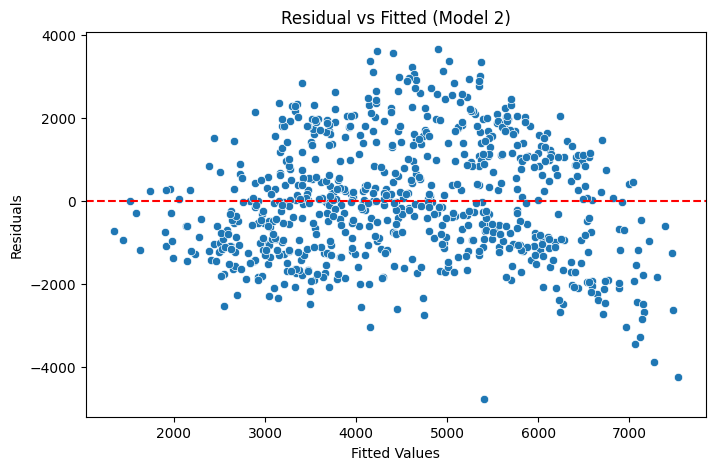

In [21]:
# ============================================================
# 14. MODEL EVALUATION: RESIDUAL ANALYSIS
# ============================================================

residuals = model2.resid
fitted = model2.fittedvalues

# Residual vs Fitted
plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual vs Fitted (Model 2)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

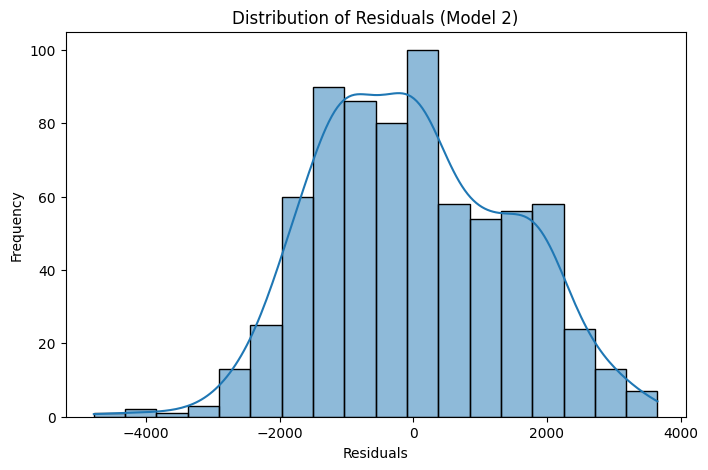

In [22]:
# Histogram of residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals (Model 2)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

### Interpretation

The residuals are mostly scattered around zero, suggesting that Model 2 is reasonable for interpretation.

The histogram is roughly centered around zero and approximately symmetric.

However, the residual spread is not perfectly constant, so the model still has imperfect fit. Prediction errors remain, so the model should not be used as the only tool for exact daily demand prediction.

## 17. Error Discussion

This section explains the meaning of the prediction error values for Model 2.

RMSE shows the typical size of prediction error, while MAE shows the average absolute prediction error.

In [23]:
# ============================================================
# 17. ERROR DISCUSSION
# ============================================================

error_discussion = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "Mean daily rentals"],
    "Model 2 Value": [
        round(rmse_model2, 2),
        round(mae_model2, 2),
        round(data["cnt"].mean(), 2)
    ],
    "Meaning": [
        "Typical prediction error in daily rentals",
        "Average absolute prediction error in daily rentals",
        "Average daily rental count for comparison"
    ]
})

display(error_discussion)

print(f"Model 2 RMSE: {rmse_model2:.2f}")
print(f"Model 2 MAE: {mae_model2:.2f}")
print(f"Average daily rentals: {data['cnt'].mean():.2f}")

,Metric,Model 2 Value,Meaning
0,RMSE,1421.40,Typical prediction error in daily rentals
1,MAE,1164.15,Average absolute prediction error in daily ren...
2,Mean daily rentals,4504.35,Average daily rental count for comparison


Model 2 RMSE: 1421.40
Model 2 MAE: 1164.15
Average daily rentals: 4504.35


### Interpretation

Model 2 improves the prediction error compared with Model 1, but the RMSE and MAE are still meaningful compared with the average daily rental count.

Also, these errors are calculated using the same dataset used to fit the model, so they are in-sample errors. For stronger prediction evaluation, future work could use a train-test split or cross-validation.

## 18. Optional Additional Analysis: 95% Confidence Intervals

This section is optional because the final report focuses mainly on hypothesis testing, model comparison, residual analysis, and error discussion.

It can be kept in the notebook as additional supporting analysis.

In [24]:
# ============================================================
# 17. OPTIONAL: 95% CONFIDENCE INTERVALS FOR COEFFICIENTS
# ============================================================

confidence_intervals = model2.conf_int()
confidence_intervals.columns = ["Lower 95%", "Upper 95%"]

print("95% Confidence Intervals for Model 2 Coefficients:")
display(confidence_intervals)

95% Confidence Intervals for Model 2 Coefficients:


,Lower 95%,Upper 95%
const,3421.061357,4747.665412
temp,6050.138045,7200.927375
hum,-3853.987908,-2346.258362
windspeed,-6198.673123,-3415.185527


## 19. Final Summary for Report

This section summarizes the main results of the project, including:

- number of observations
- response variable and predictors
- model comparison results
- hypothesis testing result
- final conclusion

In [25]:
# ============================================================
# 18. FINAL SUMMARY FOR REPORT
# ============================================================

summary_table = pd.DataFrame({
    "Item": [
        "Number of observations used",
        "Response variable",
        "Predictors",
        "Model 1",
        "Model 1 Adjusted R-squared",
        "Model 1 RMSE",
        "Model 2",
        "Model 2 Adjusted R-squared",
        "Model 2 RMSE",
        "Temperature p-value",
        "Hypothesis test decision"
    ],
    "Result": [
        data.shape[0],
        "cnt",
        "temp, hum, windspeed",
        "cnt ~ temp",
        round(model1.rsquared_adj, 4),
        round(rmse_model1, 2),
        "cnt ~ temp + hum + windspeed",
        round(model2.rsquared_adj, 4),
        round(rmse_model2, 2),
        f"{temp_pvalue_model1:.4e}",
        "Reject H0" if temp_pvalue_model1 < alpha else "Fail to reject H0"
    ]
})

display(summary_table)

,Item,Result
0,Number of observations used,731
1,Response variable,cnt
2,Predictors,"temp, hum, windspeed"
3,Model 1,cnt ~ temp
4,Model 1 Adjusted R-squared,0.3929
5,Model 1 RMSE,1507.32
6,Model 2,cnt ~ temp + hum + windspeed
7,Model 2 Adjusted R-squared,0.4587
8,Model 2 RMSE,1421.4
9,Temperature p-value,2.8106e-81


## 20. Insights and Decision-Making

### Key Findings

Temperature is positively associated with daily bike rental demand. Humidity and windspeed are negatively associated with daily bike rental demand.

Model 2 performs better than Model 1 because it has higher R-squared and Adjusted R-squared and lower prediction errors.

Therefore, Model 2 is selected as the final model. However, the model still has meaningful prediction error, so it should be used for general planning and interpretation rather than exact daily demand prediction.

### Practical Implications

Bike-sharing operators may prepare more bikes during warmer days because demand tends to increase when temperature is higher.

On more humid or windy days, demand may decrease, so operators can adjust staffing, redistribution, or maintenance planning.

## 21. Limitations

- The dataset is observational, so the results show association rather than direct causation.
- Only three weather-related predictors are included in the final model.
- Other important factors such as season, holiday, working day, weather situation, and user behavior are not included.
- The predictors are normalized, so coefficients should be interpreted on a normalized scale.
- The model still has meaningful prediction error.
- The error metrics are in-sample errors, so future work should use train-test split or cross-validation.

## 22. Conclusion

Overall, weather variables are statistically associated with daily bike rental demand.

Temperature is positively associated with bike rentals, while humidity and windspeed are negatively associated with bike rentals.

The multiple linear regression model is preferred because it explains more variation and has lower prediction error than the simple linear regression model.

However, the model should not be interpreted as proof of causation, and it should not be used as the only tool for exact daily demand prediction.